What is the most optimal skill to learn for Data Analysts?

Methodology

1.Group skills to determine median salary and likelihood of being in posting
2.Visualize median salary vs percent skill demand
3.(Optional) Determine if certain technologies are more prevalent 

In [1]:
import ast 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\DELL\anaconda3\1\envs\py11\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df_da_us=df[(df['job_title_short']=='Data Analyst') & (df['job_country']=='United States')].copy()

In [3]:
df_da_us=df_da_us.dropna(subset=['salary_year_avg'])
df_da_us_exploded=df_da_us.explode('job_skills')
df_da_us_exploded[['salary_year_avg', 'job_skills']].head(5)


,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel


In [4]:
df_da_skills=df_da_us_exploded.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count',ascending=False)
df_da_skills=df_da_skills.rename(columns={'count':'skill_count','median':'salary_median'})

da_job_count=len(df_da_us)
df_da_skills['skill_percentage']=df_da_skills['skill_count']/da_job_count*100

skill_percent=5
df_da_skills_high_demand=df_da_skills[df_da_skills['skill_percentage']>skill_percent]
df_da_skills_high_demand

,skill_count,salary_median,skill_percentage
job_skills,,,
sql,2508,91000.00,57.655172
excel,1808,84392.00,41.563218
python,1431,97500.00,32.896552
tableau,1364,92875.00,31.356322
sas,926,90000.00,21.287356
r,893,92500.00,20.528736
power bi,838,90000.00,19.264368
powerpoint,462,85000.00,10.620690
word,461,81194.75,10.597701


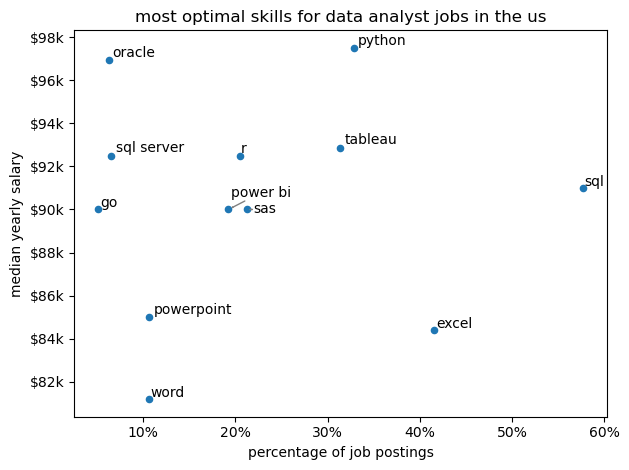

In [5]:
from adjustText import adjust_text

df_da_skills_high_demand.plot(kind='scatter', x='skill_percentage', y='salary_median')

texts=[]
for i, txt in enumerate(df_da_skills_high_demand.index):
    texts.append(plt.text(df_da_skills_high_demand['skill_percentage'].iloc[i], df_da_skills_high_demand['salary_median'].iloc[i],txt))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))
plt.title('most optimal skills for data analyst jobs in the us')
plt.xlabel('percentage of job postings')
plt.ylabel('median yearly salary')

from matplotlib.ticker import PercentFormatter
ax=plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}k'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()
plt.show()



In [6]:
df

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
1,Data Analyst,Data Analyst,"Guadalajara, Jalisco, Mexico",via BeBee México,Full-time,False,Mexico,2023-01-14 13:18:07,False,False,Mexico,NaN,NaN,NaN,Hewlett Packard Enterprise,"[r, python, sql, nosql, power bi, tableau]","{'analyst_tools': ['power bi', 'tableau'], 'pr..."
2,Data Engineer,"Data Engineer/Scientist/Analyst, Mid or Senior...","Berlin, Germany",via LinkedIn,Full-time,False,Germany,2023-10-10 13:14:55,False,False,Germany,NaN,NaN,NaN,ALPHA Augmented Services,"[python, sql, c#, azure, airflow, dax, docker,...","{'analyst_tools': ['dax'], 'cloud': ['azure'],..."
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"[python, c++, java, matlab, aws, tensorflow, k...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
4,Data Engineer,Data Engineer- Sr Jobs,"Washington, DC",via Clearance Jobs,Full-time,False,Sudan,2023-08-07 14:29:36,False,False,Sudan,NaN,NaN,NaN,Kristina Daniel,"[bash, python, oracle, aws, ansible, puppet, j...","{'cloud': ['oracle', 'aws'], 'other': ['ansibl..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785736,Software Engineer,DevOps Engineer,Singapura,melalui Trabajo.org,Pekerjaan tetap,False,Singapore,2023-03-13 06:16:16,False,False,Singapore,NaN,NaN,NaN,CAREERSTAR INTERNATIONAL PTE. LTD.,"[bash, python, perl, linux, unix, kubernetes, ...","{'os': ['linux', 'unix'], 'other': ['kubernete..."
785737,Data Analyst,CRM Data Analyst,"Bad Rodach, Jerman",melalui BeBee Deutschland,Pekerjaan tetap,False,Germany,2023-03-12 06:18:18,False,False,Germany,NaN,NaN,NaN,HABA FAMILYGROUP,"[sas, sas, sql, excel]","{'analyst_tools': ['sas', 'excel'], 'programmi..."
785738,Business Analyst,Commercial Analyst - Start Now,Malaysia,melalui Ricebowl,Pekerjaan tetap,False,Malaysia,2023-03-12 06:32:36,False,False,Malaysia,NaN,NaN,NaN,Lendlease Corporation,"[powerpoint, excel]","{'analyst_tools': ['powerpoint', 'excel']}"
785739,Data Engineer,"Principal Associate, Data Engineer (Remote-Eli...","Newark, New Jersey, Amerika Serikat",melalui Recruit.net,Pekerjaan tetap,False,Sudan,2023-03-12 06:32:15,False,False,Sudan,NaN,NaN,NaN,Capital One,"[python, go, nosql, sql, mongo, shell, mysql, ...","{'cloud': ['aws', 'snowflake', 'azure', 'redsh..."


In [7]:
df_technology=df['job_type_skills'].copy()

#remove duplicates
df_technology=df_technology.drop_duplicates()

#remove nan values
df_technology=df_technology.dropna()

#combine all dictionaries into one
technology_dict={}
for row in df_technology:
    row_dict=ast.literal_eval(row) #convert string to dict
    for key, value in row_dict.items():
        if key in technology_dict:  # if key already exists in technology dict, add value to existing key
            technology_dict[key]+=value
        else:                       # if key does not exist in technology dict, add key and value to technology dict
            technology_dict[key]=value

#remove duplicates by converting values to set then back to list
for key, value in technology_dict.items():
    technology_dict[key]=list(set(value))
technology_dict
    




{'analyst_tools': ['power bi',
  'ms access',
  'word',
  'microstrategy',
  'ssis',
  'looker',
  'powerpoint',
  'nuix',
  'qlik',
  'dax',
  'excel',
  'tableau',
  'ssrs',
  'visio',
  'datarobot',
  'alteryx',
  'esquisse',
  'sheets',
  'cognos',
  'spreadsheet',
  'sas',
  'outlook',
  'sap',
  'splunk',
  'powerbi',
  'sharepoint',
  'msaccess',
  'spss'],
 'programming': ['bash',
  'mongodb',
  'no-sql',
  'cobol',
  'c++',
  'php',
  'visualbasic',
  'elixir',
  'golang',
  'fortran',
  'scala',
  'clojure',
  'javascript',
  'solidity',
  'sql',
  'lua',
  'erlang',
  'go',
  'c#',
  'groovy',
  'f#',
  'powershell',
  'dart',
  'sass',
  'kotlin',
  'r',
  'pascal',
  'apl',
  'c',
  'haskell',
  'objective-c',
  'python',
  't-sql',
  'rust',
  'ruby',
  'ocaml',
  'matlab',
  'shell',
  'julia',
  'sas',
  'css',
  'delphi',
  'typescript',
  'nosql',
  'html',
  'swift',
  'lisp',
  'perl',
  'mongo',
  'visual basic',
  'vba',
  'vb.net',
  'crystal',
  'java',
  'assem

In [8]:
df_technology=pd.DataFrame(list(technology_dict.items()), columns=['technology','skills'])

df_technology=df_technology.explode('skills')
df_technology

,technology,skills
0,analyst_tools,power bi
0,analyst_tools,ms access
0,analyst_tools,word
0,analyst_tools,microstrategy
0,analyst_tools,ssis
...,...,...
9,sync,unify
9,sync,google chat
9,sync,wire
9,sync,rocketchat


In [9]:
df_da_skills_high_demand.head()

,skill_count,salary_median,skill_percentage
job_skills,,,
sql,2508,91000.0,57.655172
excel,1808,84392.0,41.563218
python,1431,97500.0,32.896552
tableau,1364,92875.0,31.356322
sas,926,90000.0,21.287356


In [10]:
df_plot=df_da_skills_high_demand.merge(df_technology, left_on='job_skills', right_on='skills')


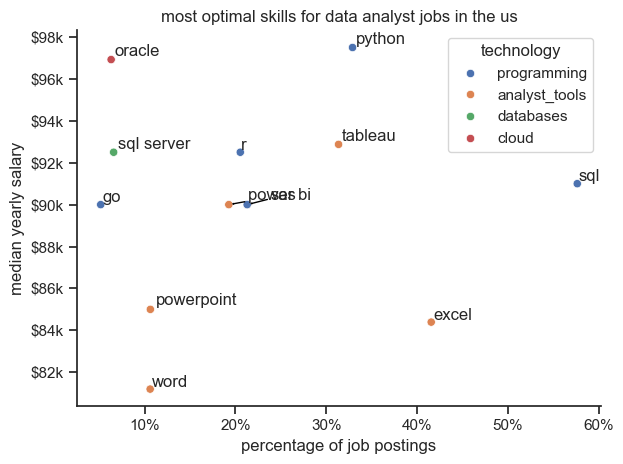

In [13]:
from adjustText import adjust_text

#df_plot.plot(kind='scatter', x='skill_percentage', y='salary_median')
sns.set_theme(style='ticks')
sns.scatterplot(data=df_plot, x='skill_percentage', y='salary_median', hue='technology')
sns.despine()


texts=[]
for i, txt in enumerate(df_da_skills_high_demand.index):
    texts.append(plt.text(df_da_skills_high_demand['skill_percentage'].iloc[i], df_da_skills_high_demand['salary_median'].iloc[i],txt))

adjust_text(texts, arrowprops=dict(arrowstyle='->', color='black'))

plt.title('most optimal skills for data analyst jobs in the us')
plt.xlabel('percentage of job postings')
plt.ylabel('median yearly salary')

from matplotlib.ticker import PercentFormatter
ax=plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}k'))
ax.xaxis.set_major_formatter(PercentFormatter(decimals=0))

plt.tight_layout()
plt.show()